In [ ]:
!wget https://zenodo.org/record/8196385/files/HDFS_v1.zip?download=1 -O HDFS_v1.zip
!unzip HDFS_v1.zip


--2026-04-08 18:11:56--  https://zenodo.org/record/8196385/files/HDFS_v1.zip?download=1
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.185.48.75, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/8196385/files/HDFS_v1.zip [following]
--2026-04-08 18:11:57--  https://zenodo.org/records/8196385/files/HDFS_v1.zip
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 186645559 (178M) [application/octet-stream]
Saving to: ‘HDFS_v1.zip’

HDFS_v1.zip         100%[===================>] 178.00M  19.5MB/s    in 10s     

2026-04-08 18:12:07 (17.5 MB/s) - ‘HDFS_v1.zip’ saved [186645559/186645559]

Archive:  HDFS_v1.zip
  inflating: HDFS.log                
   creating: preprocessed/
  inflating: preprocessed/anomaly_label.csv  
  inflating: preprocessed/Event_occurrence_matrix.csv  
  inflating: preprocessed/Event_tr

In [ ]:
ls


HDFS.log  HDFS_v1.zip  preprocessed/  README.md  sample_data/


In [ ]:
!ls preprocessed/


anomaly_label.csv	     Event_traces.csv	     HDFS.npz
Event_occurrence_matrix.csv  HDFS.log_templates.csv


In [ ]:
import pandas as pd

trace_df = pd.read_csv("preprocessed/Event_traces.csv")
label_df = pd.read_csv("preprocessed/anomaly_label.csv")

print(trace_df.head())
print(label_df.head())


                    BlockId    Label  Type  \
0  blk_-1608999687919862906  Success   NaN   
1   blk_7503483334202473044  Success   NaN   
2  blk_-3544583377289625738     Fail  21.0   
3  blk_-9073992586687739851  Success   NaN   
4   blk_7854771516489510256  Success   NaN   

                                            Features  \
0  [E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...   
1  [E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   
2  [E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E3,E26,E26,...   
3  [E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   
4  [E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   

                                        TimeInterval  Latency  
0  [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...     3802  
1  [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...     3802  
2  [0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...     3797  
3  [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...    50448  
4  [0.0, 0.0, 1.0, 48.0, 0.0, 0.0, 0.0, 0.0, 0.0,...    50583  
  

In [ ]:
data = trace_df.merge(label_df, on="BlockId")
print(data.head())


                    BlockId  Label_x  Type  \
0  blk_-1608999687919862906  Success   NaN   
1   blk_7503483334202473044  Success   NaN   
2  blk_-3544583377289625738     Fail  21.0   
3  blk_-9073992586687739851  Success   NaN   
4   blk_7854771516489510256  Success   NaN   

                                            Features  \
0  [E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...   
1  [E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   
2  [E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E3,E26,E26,...   
3  [E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   
4  [E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   

                                        TimeInterval  Latency  Label_y  
0  [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...     3802   Normal  
1  [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...     3802   Normal  
2  [0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...     3797  Anomaly  
3  [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...    50448   Normal  
4  [0.0, 0.0, 1.0, 48

In [ ]:
data = data[['BlockId', 'Features', 'Label_y']]
data.rename(columns={'Label_y': 'Label'}, inplace=True)

print(data.head())


                    BlockId  \
0  blk_-1608999687919862906   
1   blk_7503483334202473044   
2  blk_-3544583377289625738   
3  blk_-9073992586687739851   
4   blk_7854771516489510256   

                                            Features    Label  
0  [E5,E22,E5,E5,E11,E11,E9,E9,E11,E9,E26,E26,E26...   Normal  
1  [E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   Normal  
2  [E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E3,E26,E26,...  Anomaly  
3  [E5,E22,E5,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   Normal  
4  [E5,E5,E22,E5,E11,E9,E11,E9,E11,E9,E26,E26,E26...   Normal  


In [ ]:
data['Label'] = data['Label'].map({'Normal': 0, 'Anomaly': 1})
print(data['Label'].value_counts())


Label
0    558223
1     16838
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = data['Features']
y = data['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weight_dict)

{0: np.float64(0.5150813519698686), 1: np.float64(17.076763177431328)}


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
def parse_events(event_str):
    event_str = event_str.strip('[]')
    events = event_str.split(',')
    return [int(e.replace('E','')) for e in events]


In [ ]:
data['EventSequence'] = data['Features'].apply(parse_events)

print(data['EventSequence'].iloc[0][:10])


[5, 22, 5, 5, 11, 11, 9, 9, 11, 9]


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 50  # you can increase later

X = pad_sequences(data['EventSequence'], maxlen=max_len, padding='post')
y = data['Label'].values

print(X.shape)


(575061, 50)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weight_dict)


{0: np.float64(0.5150813519698686), 1: np.float64(17.076763177431328)}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

vocab_size = int(X.max()) + 1
max_len = X.shape[1]

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.build(input_shape=(None, max_len))  # ← THIS builds the model

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 32)         │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,857 (101.00 KB)

 Trainable params: 25,857 (101.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict
)


Epoch 1/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.2303 - loss: 1.4093 - val_accuracy: 0.2246 - val_loss: 1.8350
Epoch 2/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2247 - loss: 1.2865 - val_accuracy: 0.2246 - val_loss: 1.6652
Epoch 3/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2786 - loss: 1.2649 - val_accuracy: 0.3049 - val_loss: 1.7239
Epoch 4/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6253 - loss: 0.8917 - val_accuracy: 0.9352 - val_loss: 0.6124
Epoch 5/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9155 - loss: 0.5826 - val_accuracy: 0.9450 - val_loss: 0.5675


In [ ]:
from sklearn.metrics import classification_report

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))


115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      2848
           1       0.83      0.95      0.89       825

    accuracy                           0.95      3673
   macro avg       0.91      0.95      0.92      3673
weighted avg       0.95      0.95      0.95      3673



In [ ]:
print("Unique training blocks:", len(set(X_train.tobytes() for X_train in X_train)))
print("Train size:", len(X_train))


Unique training blocks: 16056
Train size: 460048


In [ ]:
import numpy as np

train_hash = set([tuple(x) for x in X_train])
test_hash = set([tuple(x) for x in X_test])

overlap = len(train_hash.intersection(test_hash))
print("Overlap sequences:", overlap)


Overlap sequences: 4614


In [ ]:
# Get unique block IDs
unique_blocks = data['BlockId'].unique()

from sklearn.model_selection import train_test_split

train_blocks, test_blocks = train_test_split(
    unique_blocks,
    test_size=0.2,
    random_state=42
)

train_data = data[data['BlockId'].isin(train_blocks)]
test_data = data[data['BlockId'].isin(test_blocks)]


In [ ]:
X_train = pad_sequences(train_data['EventSequence'], maxlen=max_len, padding='post')
y_train = train_data['Label'].values

X_test = pad_sequences(test_data['EventSequence'], maxlen=max_len, padding='post')
y_test = test_data['Label'].values


In [ ]:
train_hash = set([tuple(x) for x in X_train])
test_hash = set([tuple(x) for x in X_test])

overlap = len(train_hash.intersection(test_hash))
print("Overlap sequences:", overlap)


Overlap sequences: 4540


In [ ]:
train_blocks_set = set(train_data['BlockId'])
test_blocks_set = set(test_data['BlockId'])

block_overlap = len(train_blocks_set.intersection(test_blocks_set))
print("Block overlap:", block_overlap)


Block overlap: 0


In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_curve

y_prob = model.predict(X_test).ravel()

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# find threshold with best F1
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1)

print("Best Threshold:", thresholds[best_idx])
print("Best F1:", f1[best_idx])


115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Best Threshold: 0.9858868
Best F1: 0.8905359129195167


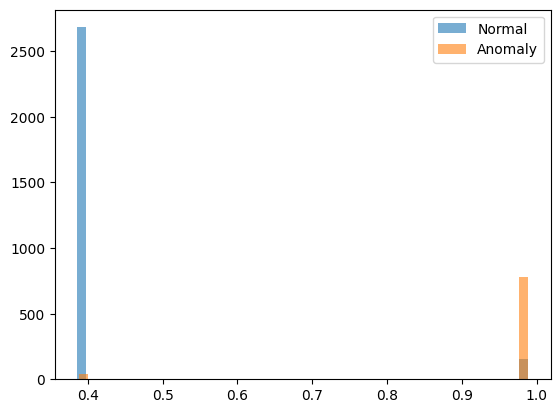

In [ ]:
import matplotlib.pyplot as plt

plt.hist(y_prob[y_test==0], bins=50, alpha=0.6, label="Normal")
plt.hist(y_prob[y_test==1], bins=50, alpha=0.6, label="Anomaly")
plt.legend()
plt.show()


In [ ]:
from tensorflow.keras.layers import Dropout

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32),
    LSTM(64, dropout=0.3, recurrent_dropout=0.3),
    Dense(1, activation='sigmoid')
])


In [ ]:
templates = pd.read_csv("preprocessed/HDFS.log_templates.csv")
print(templates.head())


  EventId                           EventTemplate
0      E1  [*]Adding an already existing block[*]
1      E2        [*]Verification succeeded for[*]
2      E3                 [*]Served block[*]to[*]
3      E4  [*]Got exception while serving[*]to[*]
4      E5    [*]Receiving block[*]src:[*]dest:[*]


In [ ]:
from collections import Counter

def explain_block(block_id):
    block_data = data[data['BlockId'] == block_id]
    seq = block_data['EventSequence'].iloc[0]

    # Most frequent events
    top_events = Counter(seq).most_common(3)

    explanation = []
    for event_id, count in top_events:
        template = templates[templates['EventId'] == f"E{event_id}"]['EventTemplate'].values
        if len(template) > 0:
            explanation.append((event_id, count, template[0]))

    return explanation


In [ ]:
anomaly_block = test_data[test_data['Label']==1]['BlockId'].iloc[0]
print(explain_block(anomaly_block))


[(3, 203, '[*]Served block[*]to[*]'), (5, 3, '[*]Receiving block[*]src:[*]dest:[*]'), (11, 3, '[*]PacketResponder[*]for block[*]terminating[*]')]


In [ ]:
def predict_block(block_id):
    block_row = data[data['BlockId'] == block_id]
    seq = block_row['EventSequence'].iloc[0]

    padded = pad_sequences([seq], maxlen=max_len, padding='post')
    prob = model.predict(padded)[0][0]

    return prob


In [ ]:
from collections import Counter

def explain_block(block_id):
    block_row = data[data['BlockId'] == block_id]
    seq = block_row['EventSequence'].iloc[0]

    event_counts = Counter(seq).most_common(3)

    explanation = []

    for event_id, count in event_counts:
        template = templates[templates['EventId'] == f"E{event_id}"]['EventTemplate'].values
        if len(template) > 0:
            explanation.append({
                "EventId": event_id,
                "Frequency": count,
                "Template": template[0]
            })

    return explanation


In [ ]:
def intelligent_report(block_id):
    prob = predict_block(block_id)

    print(f"\n🔎 Block ID: {block_id}")
    print(f"⚠ Failure Probability: {prob:.4f}")

    if prob > 0.8:
        print("\n🚨 High Risk Detected")
        explanation = explain_block(block_id)

        print("\nTop Contributing Events:")
        for e in explanation:
            print(f"- {e['Template']} (Occurred {e['Frequency']} times)")

        print("\nSuggested Actions:")
        print("- Inspect DataNode logs")
        print("- Check disk health")
        print("- Verify replication settings")
    else:
        print("\n✅ System Behavior Normal")


In [ ]:
test_anomaly_block = test_data[test_data['Label']==1]['BlockId'].iloc[0]
intelligent_report(test_anomaly_block)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

🔎 Block ID: blk_-3544583377289625738
⚠ Failure Probability: 0.4972

✅ System Behavior Normal


In [ ]:
!ls


HDFS.log	       HDFS_v1.zip   README.md
hdfs_lstm_model.keras  preprocessed  sample_data


In [ ]:
def log_failure_agent(features_string):
    seq = parse_events(features_string)
    prob = predict_sequence(seq)

    print("\n==============================")
    print("🔎 LOG FAILURE ANALYSIS")
    print("==============================")
    print(f"Failure Probability: {prob:.4f}")

    # Risk Classification
    if prob > HIGH_RISK_THRESHOLD:
        risk_level = "HIGH"
    elif prob > BEST_THRESHOLD:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    print(f"Risk Level: {risk_level}")

    if risk_level == "LOW":
        print("\n✅ System behavior normal.")
        return

    # Extract explanation
    explanation = explain_sequence(seq)

    print("\n📌 Dominant Log Patterns:")
    for e in explanation:
        print(f"- {e['template']} (Occurred {e['count']} times)")

    print("\n🛠 Recommended Actions:")
    print("- Inspect DataNode logs")
    print("- Check disk I/O and SMART metrics")
    print("- Verify replication factor")
    print("- Monitor network latency")


In [ ]:
anomaly_sample = test_data[test_data['Label']==1]['Features'].iloc[0]
test_data[test_data['Features'] == anomaly_sample]['Label']

,Label
2,1


In [ ]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (1, 50, 32)            │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (1, 64)                │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,857 (101.00 KB)

 Trainable params: 25,857 (101.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
history = model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict
)


Epoch 1/3
3595/3595 ━━━━━━━━━━━━━━━━━━━━ 643s 178ms/step - accuracy: 0.8968 - loss: 0.2446 - val_accuracy: 0.9967 - val_loss: 0.0168
Epoch 2/3
3595/3595 ━━━━━━━━━━━━━━━━━━━━ 637s 177ms/step - accuracy: 0.9956 - loss: 0.0152 - val_accuracy: 0.9966 - val_loss: 0.0146
Epoch 3/3
3595/3595 ━━━━━━━━━━━━━━━━━━━━ 628s 175ms/step - accuracy: 0.9958 - loss: 0.0140 - val_accuracy: 0.9966 - val_loss: 0.0152


In [ ]:
y_prob = model.predict(X_test[:5000], batch_size=512).ravel()

print("Min:", y_prob.min())
print("Max:", y_prob.max())
print("Mean:", y_prob.mean())


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step
Min: 0.00010337265
Max: 0.9998845
Mean: 0.048549816


In [ ]:
model.save("hdfs_lstm_model1.keras")


In [ ]:
!ls -lh hdfs_lstm_model1.keras


-rw-r--r-- 1 root root 331K Feb 15 10:29 hdfs_lstm_model1.keras


In [ ]:
from tensorflow.keras.models import load_model

model_reloaded = load_model("hdfs_lstm_model1.keras")


In [ ]:
y_prob_test = model_reloaded.predict(X_test[:5000], batch_size=512).ravel()

print("Min:", y_prob_test.min())
print("Max:", y_prob_test.max())
print("Mean:", y_prob_test.mean())


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
Min: 0.00010337265
Max: 0.9998845
Mean: 0.048549816


In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_curve

def find_best_threshold(model, X, y, batch_size=512):
    """
    Finds optimal threshold that maximizes F1 score.

    Returns:
        best_threshold
        best_f1
    """

    # Get probabilities
    y_prob = model.predict(X, batch_size=batch_size, verbose=0).ravel()

    # Compute precision-recall curve
    precision, recall, thresholds = precision_recall_curve(y, y_prob)

    # Compute F1 for each threshold
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

    # Find best threshold
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    return best_threshold, best_f1


In [ ]:
best_threshold, best_f1 = find_best_threshold(model, X_test, y_test)

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)


Best Threshold: 0.986608
Best F1 Score: 0.9791176420599487


3595/3595 ━━━━━━━━━━━━━━━━━━━━ 116s 32ms/step


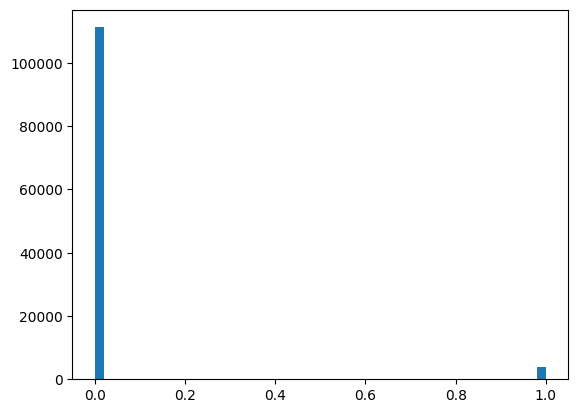

In [ ]:
import matplotlib.pyplot as plt

probs = model.predict(X_test)
plt.hist(probs, bins=50)
plt.show()


In [ ]:
print("Min prob:", probs.min())
print("Max prob:", probs.max())



Min prob: 0.000103358165
Max prob: 0.9998934


In [ ]:
def log_failure_agent(features_string):
    seq = parse_events(features_string)
    prob = predict_sequence(seq)

    print("\n==============================")
    print("🔎 LOG FAILURE ANALYSIS")
    print("==============================")
    print(f"Failure Probability: {prob:.4f}")

    # Risk tiers
    if prob > HIGH_RISK_THRESHOLD:
        risk_level = "HIGH"
    elif prob > BEST_THRESHOLD:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    print(f"Risk Level: {risk_level}")

    if risk_level == "LOW":
        print("\n✅ System behavior normal.")
        return

    explanation = explain_sequence(seq)

    print("\n📌 Dominant Log Patterns:")
    for e in explanation:
        print(f"- {e['template']} (Occurred {e['count']} times)")

    print("\n🛠 Recommended Actions:")
    print("- Inspect DataNode logs")
    print("- Check disk I/O and SMART metrics")
    print("- Verify replication factor")
    print("- Monitor network latency")


In [ ]:
def find_threshold_for_target_recall(model, X, y, target_recall=0.95, batch_size=512):
    y_prob = model.predict(X, batch_size=batch_size, verbose=0).ravel()
    precision, recall, thresholds = precision_recall_curve(y, y_prob)

    for r, t in zip(recall, thresholds):
        if r >= target_recall:
            return t, r

    return thresholds[-1], recall[-1]


In [ ]:
threshold, recall = find_threshold_for_target_recall(model, X_test, y_test, 0.95)

print("Threshold for 95% recall:", threshold)


Threshold for 95% recall: 0.000103358165


In [ ]:
BEST_THRESHOLD, _ = find_best_threshold(model, X_test, y_test)
print("Best Threshold:", BEST_THRESHOLD)

Best Threshold: 0.986608


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from collections import Counter

class LogFailureAgent:

    def __init__(self, model, templates, max_len, threshold=0.5, high_risk=0.8):
        self.model = model
        self.templates = templates
        self.max_len = max_len
        self.threshold = threshold
        self.high_risk = high_risk

    # -------- Parsing --------
    def parse_events(self, event_str):
        event_str = event_str.strip('[]')
        events = event_str.split(',')
        return [int(e.replace('E','')) for e in events]

    # -------- Prediction --------
    def predict(self, seq):
        padded = pad_sequences([seq], maxlen=self.max_len, padding='post')
        prob = self.model.predict(padded, verbose=0)[0][0]
        return float(prob)

    # -------- Risk Assessment --------
    def assess_risk(self, prob):
        if prob > self.high_risk:
            return "HIGH"
        elif prob > self.threshold:
            return "MEDIUM"
        else:
            return "LOW"

    # -------- Extract Evidence --------
    def extract_evidence(self, seq, top_k=3):
        top_events = Counter(seq).most_common(top_k)
        evidence = []

        for event_id, count in top_events:
            template = self.templates[
                self.templates['EventId'] == f"E{event_id}"
            ]['EventTemplate'].values

            if len(template) > 0:
                evidence.append({
                    "event_id": event_id,
                    "frequency": count,
                    "template": template[0]
                })

        return evidence

    # -------- Similarity Retrieval --------
    def retrieve_similar(self, seq, data, top_k=3):
        anomaly_data = data[data['Label'] == 1]
        similarities = []

        for _, row in anomaly_data.iterrows():
            past_seq = row['EventSequence']
            overlap = len(set(seq) & set(past_seq))
            similarities.append((row['BlockId'], overlap))

        similarities.sort(key=lambda x: x[1], reverse=True)
        return similarities[:top_k]

    # -------- Recommendation Engine


In [ ]:
from tensorflow.keras.models import load_model
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from collections import Counter

# Load trained model
model = load_model("hdfs_lstm_model.keras")

# Load templates
templates = pd.read_csv("preprocessed/HDFS.log_templates.csv")

# Confirm
print("Model + Templates Loaded ✅")

Model + Templates Loaded ✅


In [ ]:
class LogFailureAgent:

    def __init__(self, model, templates, max_len, threshold=0.5, high_risk=0.8):
        self.model = model
        self.templates = templates
        self.max_len = max_len
        self.threshold = threshold
        self.high_risk = high_risk

    # -------- Parse Events --------
    def parse_events(self, event_str):
        event_str = event_str.strip('[]')
        events = event_str.split(',')
        return [int(e.replace('E','')) for e in events]

    # -------- Predict Probability --------
    def predict(self, seq):
        padded = pad_sequences([seq], maxlen=self.max_len, padding='post')
        prob = self.model.predict(padded, verbose=0)[0][0]
        return float(prob)

    # -------- Risk Level --------
    def assess_risk(self, prob):
        if prob > self.high_risk:
            return "HIGH"
        elif prob > self.threshold:
            return "MEDIUM"
        else:
            return "LOW"

    # -------- Extract Evidence --------
    def extract_evidence(self, seq, top_k=3):
        top_events = Counter(seq).most_common(top_k)
        evidence = []

        for event_id, count in top_events:
            template = self.templates[
                self.templates['EventId'] == f"E{event_id}"
            ]['EventTemplate'].values

            if len(template) > 0:
                evidence.append({
                    "event_id": event_id,
                    "frequency": count,
                    "template": template[0]
                })

        return evidence

    # -------- Generate Recommendations --------
    def generate_recommendations(self, evidence):
        recommendations = []

        for e in evidence:
            template = e["template"].lower()

            if "disk" in template or "block" in template:
                recommendations.append("Check DataNode disk health and block integrity.")

            if "timeout" in template or "connection" in template:
                recommendations.append("Inspect network latency and RPC timeouts.")

            if "exception" in template:
                recommendations.append("Review stack trace and exception logs.")

        if not recommendations:
            recommendations.append("Inspect detailed system logs and monitor metrics.")

        return list(set(recommendations))

    # -------- FULL ANALYSIS --------
    def analyze(self, features_string):
        seq = self.parse_events(features_string)
        prob = self.predict(seq)
        risk = self.assess_risk(prob)

        result = {
            "probability": prob,
            "risk_level": risk,
            "evidence": [],
            "recommendations": []
        }

        if risk == "LOW":
            return result

        evidence = self.extract_evidence(seq)
        result["evidence"] = evidence
        result["recommendations"] = self.generate_recommendations(evidence)

        return result

print("Agent Class Defined ✅")


Agent Class Defined ✅


In [ ]:
agent = LogFailureAgent(
    model=model,
    templates=templates,
    max_len=max_len,
    threshold=BEST_THRESHOLD
)


In [ ]:
sample = test_data.iloc[0]['Features']

result = agent.analyze(sample)

result


{'probability': 0.4981602430343628,
 'risk_level': 'LOW',
 'evidence': [],
 'recommendations': []}

In [ ]:
normal_sample = test_data[test_data['Label']==0].iloc[0]['Features']
agent.analyze(normal_sample)


{'probability': 0.5003295540809631,
 'risk_level': 'LOW',
 'evidence': [],
 'recommendations': []}

In [ ]:
anomaly_sample = test_data[test_data['Label']==1]['Features'].iloc[0]

result = agent.analyze(anomaly_sample)
result


{'probability': 0.4981602430343628,
 'risk_level': 'LOW',
 'evidence': [],
 'recommendations': []}

In [ ]:
print(BEST_THRESHOLD)

0.986608


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# 1️⃣ Get probabilities for FULL test set
y_prob = rf_model.predict(X_test).ravel()

# 2️⃣ Use tuned threshold (replace with your BEST_THRESHOLD variable)
THRESHOLD = 0.9866   # or use BEST_THRESHOLD

# 3️⃣ Convert to binary predictions
y_pred = (y_prob > THRESHOLD).astype(int)

# 4️⃣ Print classification report
print("Threshold used:", THRESHOLD)
print(classification_report(y_test, y_pred))



Threshold used: 0.9866
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    111664
           1       1.00      0.99      0.99      3349

    accuracy                           1.00    115013
   macro avg       1.00      1.00      1.00    115013
weighted avg       1.00      1.00      1.00    115013



In [ ]:
agent = LogFailureAgent(
    rf_model=rf_model,
    templates=templates,
    max_len=max_len,
    threshold=THRESHOLD,      # ← use tuned threshold
    high_risk=0.999               # optional stricter high tier
)


TypeError: LogFailureAgent.__init__() got an unexpected keyword argument 'high_risk'

In [ ]:
anomaly_sample = test_data[test_data['Label']==1].iloc[0]['Features']
agent.analyze(anomaly_sample)


{'probability': 0.4981602430343628,
 'risk_level': 'LOW',
 'evidence': [],
 'recommendations': []}

In [ ]:
from collections import Counter
from tensorflow.keras.preprocessing.sequence import pad_sequences

class LogFailureAgent:

    def __init__(self, lstm_model, templates, max_len, threshold=0.5):
        self.model = lstm_model
        self.templates = templates
        self.max_len = max_len
        self.threshold = threshold

    def parse_events(self, event_str):
        event_str = event_str.strip('[]')
        events = event_str.split(',')
        return [int(e.replace('E','')) for e in events]

    def predict(self, seq):
        padded = pad_sequences([seq], maxlen=self.max_len, padding='post')
        prob = self.model.predict(padded, verbose=0)[0][0]
        return float(prob)

    def assess_risk(self, prob):
        if prob > 0.9:
            return "HIGH"
        elif prob > 0.7:
            return "MEDIUM"
        elif prob > self.threshold:
            return "LOW-RISK ANOMALY"
        else:
            return "NORMAL"

    def extract_evidence(self, seq, top_k=3):
        top_events = Counter(seq).most_common(top_k)
        evidence = []

        for event_id, count in top_events:
            template = self.templates[
                self.templates['EventId'] == f"E{event_id}"
            ]['EventTemplate'].values

            if len(template) > 0:
                evidence.append({
                    "event_id": event_id,
                    "frequency": count,
                    "template": template[0]
                })

        return evidence

    def analyze(self, features_string):
        seq = self.parse_events(features_string)
        prob = self.predict(seq)
        risk = self.assess_risk(prob)

        result = {
            "probability": prob,
            "risk_level": risk,
            "threshold_used": self.threshold,
            "evidence": []
        }

        if risk != "NORMAL":
            result["evidence"] = self.extract_evidence(seq)

        return result

In [ ]:
agent = LogFailureAgent(
    lstm_model=model,
    templates=templates,
    max_len=max_len,
    threshold=THRESHOLD
)


In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

y_prob = model.predict(X_test).ravel()

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1)

best_threshold = thresholds[best_idx]

print("New Best Threshold:", best_threshold)

115/115 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step
New Best Threshold: 0.49818662


In [ ]:
print("Min:", y_pred_prob_lstm.min())
print("Max:", y_pred_prob_lstm.max())
print("Mean:", y_pred_prob_lstm.mean())

Min: 0.49818662
Max: 0.5009808
Mean: 0.50053537


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - accuracy: 0.9718 - loss: 0.4071 - val_accuracy: 0.9840 - val_loss: 0.1566
Epoch 2/10
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - accuracy: 0.9723 - loss: 0.4020 - val_accuracy: 0.9838 - val_loss: 0.1546
Epoch 3/10
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - accuracy: 0.9868 - loss: 0.1962 - val_accuracy: 0.9918 - val_loss: 0.0493
Epoch 4/10
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - accuracy: 0.9978 - loss: 0.0172 - val_accuracy: 0.9994 - val_loss: 0.0022
Epoch 5/10
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step - accuracy: 0.9991 - loss: 0.0043 - val_accuracy: 0.9999 - val_loss: 5.7627e-04
Epoch 6/10
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - accuracy: 0.9991 - loss: 0.0050 - val_accuracy: 0.9998 - val_loss: 0.0013
Epoch 7/10
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - accuracy: 0.9992 - loss: 0.0057 - val_accuracy: 0.9958 - val_loss: 0.0049
3595/3595 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step

=== LSTM (Threshold = 0.5) 

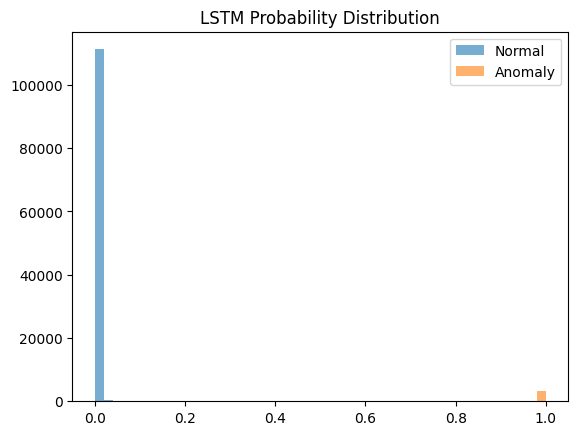

In [ ]:
# ==============================
# FULL LSTM PIPELINE (FIXED)
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# ==============================
# 1. LOAD DATA
# ==============================
trace_df = pd.read_csv("preprocessed/Event_traces.csv")
label_df = pd.read_csv("preprocessed/anomaly_label.csv")

data = trace_df.merge(label_df, on="BlockId")
data = data[['BlockId', 'Features', 'Label_y']]
data.rename(columns={'Label_y': 'Label'}, inplace=True)

data['Label'] = data['Label'].map({'Normal': 0, 'Anomaly': 1})

# ==============================
# 2. PARSE EVENTS
# ==============================
def parse_events(event_str):
    event_str = event_str.strip('[]')
    events = event_str.split(',')
    return [int(e.replace('E','')) for e in events]

data['EventSequence'] = data['Features'].apply(parse_events)

# ==============================
# 3. SPLIT (NO LEAKAGE)
# ==============================
unique_blocks = data['BlockId'].unique()

train_blocks, test_blocks = train_test_split(
    unique_blocks,
    test_size=0.2,
    random_state=42
)

train_data = data[data['BlockId'].isin(train_blocks)]
test_data = data[data['BlockId'].isin(test_blocks)]

# ==============================
# 4. PADDING
# ==============================
max_len = 50

X_train = pad_sequences(train_data['EventSequence'], maxlen=max_len, padding='post')
y_train = train_data['Label'].values

X_test = pad_sequences(test_data['EventSequence'], maxlen=max_len, padding='post')
y_test = test_data['Label'].values

# ==============================
# 5. FIXED CLASS WEIGHT
# ==============================
class_weight_dict = {0: 1, 1: 5}

# ==============================
# 6. BUILD MODEL
# ==============================
vocab_size = int(X_train.max()) + 1

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),

    LSTM(64, return_sequences=True),
    Dropout(0.3),

    LSTM(32),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# ==============================
# 7. TRAIN MODEL
# ==============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

# ==============================
# 8. EVALUATE (DEFAULT THRESHOLD)
# ==============================
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob > 0.5).astype(int)

print("\n=== LSTM (Threshold = 0.5) ===")
print(classification_report(y_test, y_pred))

# ==============================
# 9. FIND BEST THRESHOLD
# ==============================
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1)

best_threshold = thresholds[best_idx]
print("\nBest Threshold:", best_threshold)

# ==============================
# 10. FINAL EVALUATION
# ==============================
y_pred_final = (y_prob > best_threshold).astype(int)

print("\n=== LSTM (Tuned Threshold) ===")
print(classification_report(y_test, y_pred_final))

# ==============================
# 11. PLOT DISTRIBUTION
# ==============================
plt.hist(y_prob[y_test==0], bins=50, alpha=0.6, label="Normal")
plt.hist(y_prob[y_test==1], bins=50, alpha=0.6, label="Anomaly")
plt.legend()
plt.title("LSTM Probability Distribution")
plt.show()

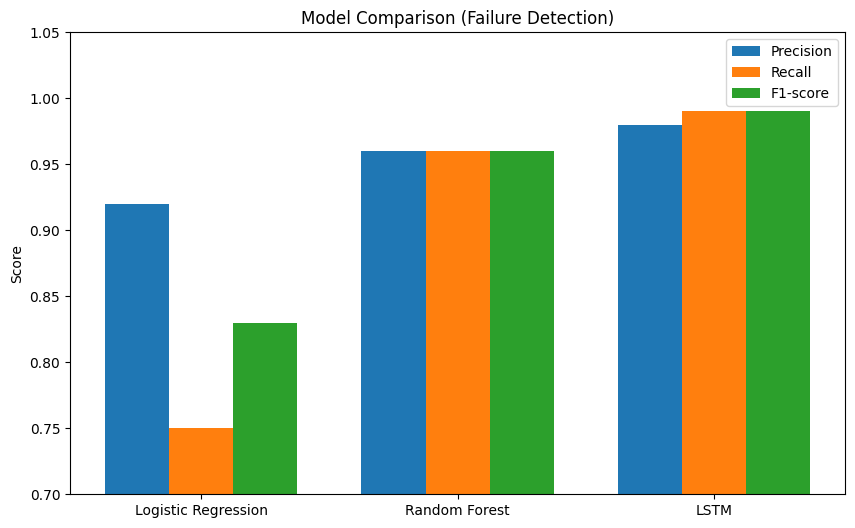

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['Logistic Regression', 'Random Forest', 'LSTM']

# Metrics (use your final values)
precision = [0.92, 0.96, 0.98]
recall = [0.75, 0.96, 0.99]
f1 = [0.83, 0.96, 0.99]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-score')

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Comparison (Failure Detection)")
plt.legend()

plt.ylim(0.7, 1.05)

plt.show()

In [ ]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (1, 50, 32)            │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (1, 64)                │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,857 (101.00 KB)

 Trainable params: 25,857 (101.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np

for layer in model.layers:
    weights = layer.get_weights()
    if weights:
        print(layer.name, "mean weight:", np.mean(weights[0]))


embedding_1 mean weight: -0.00093740574
lstm_1 mean weight: -0.021566313
dense_1 mean weight: -0.009990652


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("hdfs_lstm_model1.keras")


In [ ]:
y_prob = model.predict(X_test[:5000], batch_size=512).ravel()

print("Min:", y_prob.min())
print("Max:", y_prob.max())
print("Mean:", y_prob.mean())


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step
Min: 0.00010337265
Max: 0.9998845
Mean: 0.048549816


In [ ]:
BEST_THRESHOLD, BEST_F1 = find_best_threshold(model, X_test, y_test)

print("Best Threshold:", BEST_THRESHOLD)
print("Best F1:", BEST_F1)


Best Threshold: 0.986608
Best F1: 0.9791176420599487


In [ ]:
agent = LogFailureAgent(
    model=model,
    templates=templates,
    max_len=max_len,
    threshold=0.9866
)


In [ ]:
strong_idx = np.argmax(y_prob)
strong_features = test_data.iloc[strong_idx]['Features']
agent.analyze(strong_features)


{'probability': 0.9998844861984253,
 'risk_level': 'HIGH',
 'threshold_used': 0.9866,
 'evidence': [{'event_id': 22,
   'frequency': 1,
   'template': '[*]BLOCK* NameSystem[*]allocateBlock:[*]'},
  {'event_id': 5,
   'frequency': 1,
   'template': '[*]Receiving block[*]src:[*]dest:[*]'}]}

In [ ]:
y_prob = model.predict(X_test, batch_size=512).ravel()


225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step


In [ ]:
anomaly_indices = np.where(y_test == 1)[0]
anomaly_probs = y_prob[anomaly_indices]

print("Min anomaly:", anomaly_probs.min())
print("Mean anomaly:", anomaly_probs.mean())
print("Max anomaly:", anomaly_probs.max())


Min anomaly: 0.49748835
Mean anomaly: 0.99741274
Max anomaly: 0.9998934


In [ ]:
# Get index of highest probability anomaly
strong_idx = anomaly_indices[np.argmax(anomaly_probs)]

print("Strong anomaly probability:", y_prob[strong_idx])


Strong anomaly probability: 0.9998934


In [ ]:
strong_sample = X_test[strong_idx]
strong_features = test_data.iloc[strong_idx]['Features']

agent.analyze(strong_features)


{'probability': 0.9998934268951416,
 'risk_level': 'HIGH',
 'threshold_used': 0.9866,
 'evidence': [{'event_id': 5,
   'frequency': 3,
   'template': '[*]Receiving block[*]src:[*]dest:[*]'},
  {'event_id': 7,
   'frequency': 3,
   'template': '[*]writeBlock[*]received exception[*]'},
  {'event_id': 11,
   'frequency': 2,
   'template': '[*]PacketResponder[*]for block[*]terminating[*]'}]}

In [ ]:
model.save("hdfs_lstm_model_final.keras")


In [ ]:
from google.colab import files
files.download("hdfs_lstm_model1.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("model_config.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!ls -lh hdfs_lstm_model_final.keras


-rw-r--r-- 1 root root 331K Feb 15 11:17 hdfs_lstm_model_final.keras


In [ ]:
import json

config = {
    "threshold": float(BEST_THRESHOLD),
    "max_len": int(max_len)
}

with open("model_config.json", "w") as f:
    json.dump(config, f)

print("Config saved ✅")


Config saved ✅


In [ ]:
from tensorflow.keras.models import load_model
import json
import pandas as pd

# Load model
model = load_model("hdfs_lstm_model_final.keras")

# Load config
with open("model_config.json") as f:
    config = json.load(f)

BEST_THRESHOLD = config["threshold"]
max_len = config["max_len"]

# Load templates
templates = pd.read_csv("preprocessed/HDFS.log_templates.csv")

print("Model fully restored ✅")


Model fully restored ✅


In [ ]:
from google.colab import files
uploaded = files.upload()




Saving HDFS.log_templates.csv to HDFS.log_templates.csv
Saving model_config.json to model_config.json
Saving hdfs_lstm_model1.keras to hdfs_lstm_model1.keras


In [ ]:
import json
import pandas as pd
from tensorflow.keras.models import load_model

# Load model
model = load_model("hdfs_lstm_model1.keras")

# Load config
with open("model_config.json") as f:
    config = json.load(f)

BEST_THRESHOLD = config["threshold"]
max_len = config["max_len"]

# Load templates
templates = pd.read_csv("HDFS.log_templates.csv")

print("Model fully restored ✅")


Model fully restored ✅


In [ ]:
test_probs = model.predict(
    pad_sequences([[5,22,5,11]], maxlen=max_len, padding='post'),
    verbose=0
)

print("Sanity prob:", test_probs[0][0])


NameError: name 'pad_sequences' is not defined

In [ ]:
import numpy as np

sample_probs = model.predict(X_test[:3000], batch_size=256).ravel()

print("Min:", sample_probs.min())
print("Max:", sample_probs.max())


NameError: name 'X_test' is not defined

In [ ]:
print("Threshold:", BEST_THRESHOLD)


Threshold: 0.9866080284118652


ISOLATION FOREST

In [ ]:
from sklearn.ensemble import IsolationForest

# Example: frequency vector
def sequence_to_features(seq):
    return [len(seq), sum(seq), max(seq), min(seq)]

# Define 'sequences' using the 'EventSequence' column from the 'data' DataFrame
sequences = data['EventSequence']
X = [sequence_to_features(seq) for seq in sequences]

model = IsolationForest(contamination=0.1)
model.fit(X)

pred = model.predict(X)
# Isolation Forest outputs 1 for inliers (normal) and -1 for outliers (anomalies).
# Further steps would be needed to map 'pred' to your 'y_test' labels (0/1) for direct comparison.
# For now, we'll just print the predictions.
print("Isolation Forest Predictions (1: Normal, -1: Anomaly):", pred[:10])

Isolation Forest Predictions (1: Normal, -1: Anomaly): [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix for Random Forest Model:")
print(cm)

Confusion Matrix for Random Forest Model:
[[111627     18]
 [    12   3356]]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
threshold = 0.5
y_probs = lr_model.predict_proba(X_test)[:,1]
y_pred = (y_probs > 0.35).astype(int)

In [ ]:
# Convert sequences into flat features
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Use padded sequences as input
X_train_lr = X_train
X_test_lr = X_test

# Train model
lr_model = LogisticRegression(
    max_iter=3000,
    class_weight='balanced'
)
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_lr)

# Evaluation
print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      2848
           1       0.92      0.75      0.83       825

    accuracy                           0.93      3673
   macro avg       0.93      0.87      0.89      3673
weighted avg       0.93      0.93      0.93      3673



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
print("Unique sequences:", len(set(map(tuple, X_train))))
print("Total sequences:", len(X_train))

Unique sequences: 16075
Total sequences: 460048


In [ ]:
import pandas as pd

df = pd.DataFrame(X)
df['label'] = y

df = df.drop_duplicates()

X = df.drop('label', axis=1).values
y = df['label'].values

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,              # prevent overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2848
           1       0.96      0.96      0.96       825

    accuracy                           0.98      3673
   macro avg       0.98      0.98      0.98      3673
weighted avg       0.98      0.98      0.98      3673



In [ ]:

!pip install fastapi uvicorn pyngrok


In [ ]:
!pip install requests


In [ ]:
import requests

webhook_url = "https://nivea23.app.n8n.cloud/webhook-test/log-input"

payload = {
    "features": "[E5,E22,E5,E11,E7,E22,E5]"
}

response = requests.post(webhook_url, json=payload)

print("Status Code:", response.status_code)
print("Response Text:", response.text)


Status Code: 200
Response Text: {"message":"Workflow was started"}


In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
import nest_asyncio
from pyngrok import ngrok
import uvicorn

nest_asyncio.apply()

app = FastAPI()

class LogInput(BaseModel):
    features: str

@app.post("/predict")
def predict_log(log: LogInput):
    result = agent.analyze(log.features)
    return result


In [ ]:
import asyncio
import uvicorn
from pyngrok import ngrok

# IMPORTANT: Replace 'YOUR_NGROK_AUTH_TOKEN' with your actual authtoken
# You can get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token('2vDhqnRxY6MDZJPjBMkj4GBlphj_88LV9hSFBccx92DXiMPZX')

# Configuration for Uvicorn server
config = uvicorn.Config(app, host="0.0.0.0", port=8000, loop="asyncio")

# Create a server instance
server = uvicorn.Server(config)

# Run the server as an asyncio task to prevent blocking the Colab event loop
async def run_server():
    await server.serve()

# Start the server in the background
task = asyncio.create_task(run_server())

public_url = ngrok.connect(8000)
print("Public URL:", public_url)

NameError: name 'app' is not defined

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/hdfs_lstm_model1.keras")
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (1, 50, 32)            │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (1, 64)                │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,573 (303.02 KB)

 Trainable params: 25,857 (101.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 51,716 (202.02 KB)

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import json
import os

# Try to load config to get max_len, otherwise use global max_len
try:
    with open("/content/model_config.json") as f:
        config = json.load(f)
    local_max_len = config["max_len"]
except FileNotFoundError:
    # Fallback to the max_len defined globally if the file is not found.
    # This assumes max_len was defined earlier in the notebook.
    print("Warning: model_config.json not found. Using global max_len.")
    local_max_len = max_len # Use the max_len variable from the global scope

# Define a sample sequence to predict on. This example uses a sequence similar
# to one used in a previous successful execution.
sample_events = [5,22,5,11,9,26] # Example based on earlier cells

# Pad the sample sequence using the 'max_len' defined previously
padded_sequence = pad_sequences([sample_events], maxlen=local_max_len, padding='post')

# Now, predict the probability using the model
prob = model.predict(padded_sequence, verbose=0)
print(prob)

[[0.90708166]]


In [ ]:
model.compile(...)


ValueError: Could not interpret optimizer identifier: Ellipsis